<h2><strong>Section 1: Setup and Data Loading</strong></h2>

In [7]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, precision_score, recall_score
from xgboost import XGBClassifier
import joblib
from geopy.distance import geodesic
from tqdm import tqdm
tqdm.pandas()

print("Libraries imported successfully")

Libraries imported successfully


In [8]:
# Load dataset
df = pd.read_csv('geo_linked_with_entity.csv')

# Convert event_time to datetime
df['event_time'] = pd.to_datetime(df['event_time'])
df['date'] = df['event_time'].dt.date

print(f"Dataset loaded with {len(df)} records")
print("Columns:", df.columns.tolist())
df.head()

Dataset loaded with 723318 records
Columns: ['link_id', 'entity_id', 'label_isFraud', 'client_id', 'event_time', 'latitude', 'longitude', 'composite_suspicion_score', 'geo_day_int', 'geo_band', 'date']


,link_id,entity_id,label_isFraud,client_id,event_time,latitude,longitude,composite_suspicion_score,geo_day_int,geo_band,date
0,0,0,1,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-08 08:23:53,-89.978027,-134.934082,NaN,19000.0,mid,2022-01-08
1,1,0,1,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-09 06:20:43,-89.978027,-134.934082,0.299014,19001.0,mid,2022-01-09
2,2,0,1,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-10 06:17:25,-89.978027,-134.934082,0.219014,19002.0,mid,2022-01-10
3,3,0,0,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-11 14:31:30,-89.978027,-134.934082,0.099014,19003.0,low,2022-01-11
4,4,0,0,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-14 07:57:30,-89.978027,-134.934082,0.099014,19006.0,low,2022-01-14


<h2><strong>Section 2: Geographic Risk Zone Analysis</strong></h2>

In [9]:
# Identify high-risk geographic zones based on historical fraud patterns
def extract_risk_zones_from_data(df, grid_size=0.1, min_transactions=10, risk_threshold=0.7):
    print("Analyzing geographic risk zones...")
    
    # Create a grid of geographic areas
    df['lat_bin'] = np.round(df['latitude'] / grid_size) * grid_size
    df['lon_bin'] = np.round(df['longitude'] / grid_size) * grid_size
    
    # Calculate fraud rate by geographic bin
    geo_risk = df.groupby(['lat_bin', 'lon_bin']).agg({
        'label_isFraud': ['mean', 'count']
    }).reset_index()
    
    # Flatten column names
    geo_risk.columns = ['lat_bin', 'lon_bin', 'fraud_rate', 'transaction_count']
    
    # Filter for significant risk zones
    risk_zones = []
    for _, row in geo_risk.iterrows():
        if (row['fraud_rate'] >= risk_threshold and 
            row['transaction_count'] >= min_transactions):
            # Define a zone around the bin center
            risk_zones.append((
                row['lat_bin'] - grid_size/2,  # min_lat
                row['lat_bin'] + grid_size/2,  # max_lat
                row['lon_bin'] - grid_size/2,  # min_lon
                row['lon_bin'] + grid_size/2,  # max_lon
                row['fraud_rate']  # risk score
            ))
    
    print(f"Identified {len(risk_zones)} high-risk geographic zones")
    return risk_zones

# Extract risk zones from your data
risk_zones = extract_risk_zones_from_data(df)
risk_zones_df = pd.DataFrame(risk_zones, columns=['min_lat', 'max_lat', 'min_lon', 'max_lon', 'risk_score'])
risk_zones_df.head()

Analyzing geographic risk zones...
Identified 316 high-risk geographic zones


,min_lat,max_lat,min_lon,max_lon,risk_score
0,-89.75,-89.65,-108.85,-108.75,0.750000
1,-89.45,-89.35,-65.95,-65.85,0.736842
2,-88.55,-88.45,-74.45,-74.35,0.777778
3,-88.55,-88.45,-42.75,-42.65,0.833333
4,-88.05,-87.95,-30.45,-30.35,0.785714


In [10]:
# Simulate real-time feature calculation from historical data
def create_real_time_features(df):
    print("Creating real-time features from historical data...")
    
    # Sort by client and time to simulate transaction order
    df = df.sort_values(['client_id', 'event_time']).copy()
    # Drop rows with missing or non-finite coordinates to avoid geodesic errors
    df = df[np.isfinite(df['latitude']) & np.isfinite(df['longitude'])].copy()
    
    # Initialize dictionaries to track client state (simulating the real-time engine)
    client_profiles = {}
    results = []
    
    # Process each transaction in order
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        client_id = row['client_id']
        timestamp = row['event_time']
        lat = row['latitude']
        lon = row['longitude']
        
        # Initialize client profile if new client
        if client_id not in client_profiles:
            client_profiles[client_id] = {
                'first_seen': timestamp,
                'last_seen': timestamp,
                'home_location': (lat, lon),
                'transaction_count': 0,
                'last_location': (lat, lon),
                'last_timestamp': timestamp,
                'locations': []
            }
        
        profile = client_profiles[client_id]
        
        # Calculate features for this transaction
        features = {}
        
        # 1. Geographic risk
        geo_risk = 0
        for min_lat, max_lat, min_lon, max_lon, zone_risk in risk_zones:
            if min_lat <= lat <= max_lat and min_lon <= lon <= max_lon:
                geo_risk = max(geo_risk, zone_risk)
        features['geo_risk'] = geo_risk
        
        # 2. Distance from home
        home_lat, home_lon = profile['home_location']
        features['distance_from_home'] = geodesic((home_lat, home_lon), (lat, lon)).km
        
        # 3. Velocity (if not first transaction)
        if profile['transaction_count'] > 0:
            last_lat, last_lon = profile['last_location']
            last_time = profile['last_timestamp']
            time_diff_hours = (timestamp - last_time).total_seconds() / 3600
            
            if time_diff_hours > 0:
                distance = geodesic((last_lat, last_lon), (lat, lon)).km
                features['velocity_kmh'] = distance / time_diff_hours
            else:
                features['velocity_kmh'] = 0
        else:
            features['velocity_kmh'] = 0
        
        # 4. Temporal features
        features['hour_of_day'] = timestamp.hour
        features['is_night'] = 1 if (timestamp.hour >= 22 or timestamp.hour <= 6) else 0
        features['day_of_week'] = timestamp.weekday()
        features['is_weekend'] = 1 if timestamp.weekday() >= 5 else 0
        
        # 5. Behavioral features
        features['transaction_count'] = profile['transaction_count']
        features['client_age_days'] = (timestamp - profile['first_seen']).days
        
        # Add the actual label for training
        features['label_isFraud'] = row['label_isFraud']
        features['client_id'] = client_id
        features['event_time'] = timestamp
        
        results.append(features)
        
        # Update client profile
        profile['last_seen'] = timestamp
        profile['transaction_count'] += 1
        profile['last_location'] = (lat, lon)
        profile['last_timestamp'] = timestamp
        profile['locations'].append((lat, lon, timestamp))
        
        # Update home location (median of all locations)
        if len(profile['locations']) > 0:
            all_lats = [loc[0] for loc in profile['locations']]
            all_lons = [loc[1] for loc in profile['locations']]
            profile['home_location'] = (np.median(all_lats), np.median(all_lons))
    
    return pd.DataFrame(results)

# Create and Save the real-time features DataFrame
rt_features_df = create_real_time_features(df)
rt_features_df.to_pickle('real_time_features.pkl')
print("Real-time features created. Shape:", rt_features_df.shape)
rt_features_df.head()

Creating real-time features from historical data...


100%|██████████| 723317/723317 [03:09<00:00, 3817.13it/s]


Real-time features created. Shape: (723317, 12)


,geo_risk,distance_from_home,velocity_kmh,hour_of_day,is_night,day_of_week,is_weekend,transaction_count,client_age_days,label_isFraud,client_id,event_time
0,0.0,0.0,0.0,8,0,5,1,0,0,1,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-08 08:23:53
1,0.0,0.0,0.0,6,1,6,1,1,0,1,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-09 06:20:43
2,0.0,0.0,0.0,6,1,0,0,2,1,1,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-10 06:17:25
3,0.0,0.0,0.0,14,0,1,0,3,3,0,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-11 14:31:30
4,0.0,0.0,0.0,7,0,4,0,4,5,0,0001edbc5ab720f70a615ed9e8429df9b6c3f3c3999a51...,2022-01-14 07:57:30


<h2><strong>Section 4: Train the Real-Time Model</strong></h2>

In [11]:
# Load the real-time features from saved file
rt_features_df = pd.read_pickle('real_time_features.pkl')
print("Real-time features loaded from 'real_time_features.pkl'")
print(f"Dataset shape: {rt_features_df.shape}")

# Prepare features and labels for training
# Define the feature set that will be available in real-time
feature_columns = [
    'geo_risk', 'distance_from_home', 'velocity_kmh', 
    'hour_of_day', 'is_night', 'day_of_week', 'is_weekend',
    'transaction_count', 'client_age_days'
]

X = rt_features_df[feature_columns]
y = rt_features_df['label_isFraud']

print(f"Training set shape: {X.shape}")
print(f"Fraud rate in training set: {y.mean():.4f}")

# Handle missing values (velocity will be NaN for first transactions)
X = X.fillna(0)

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets (time-based split)
# Use the date from the original event_time
rt_features_df['date'] = rt_features_df['event_time'].dt.date
all_dates = sorted(rt_features_df['date'].unique())
split_idx = int(len(all_dates) * 0.8)
train_dates = all_dates[:split_idx]
test_dates = all_dates[split_idx:]

X_train = X_scaled[rt_features_df['date'].isin(train_dates)]
X_test = X_scaled[rt_features_df['date'].isin(test_dates)]
y_train = y[rt_features_df['date'].isin(train_dates)]
y_test = y[rt_features_df['date'].isin(test_dates)]

print(f"Train set: {X_train.shape[0]} records ({train_dates[0]} to {train_dates[-1]})")
print(f"Test set: {X_test.shape[0]} records ({test_dates[0]} to {test_dates[-1]})")

Real-time features loaded from 'real_time_features.pkl'
Dataset shape: (723317, 12)
Training set shape: (723317, 9)
Fraud rate in training set: 0.4187
Train set: 570924 records (2021-12-11 to 2022-10-14)
Test set: 152393 records (2022-10-15 to 2022-12-31)


In [12]:
# Calculate the precise imbalance ratio
fraud_ratio = y_train.mean()
non_fraud_ratio = 1 - fraud_ratio
imbalance_ratio = non_fraud_ratio / fraud_ratio

print(f"Fraud ratio: {fraud_ratio:.4f}")
print(f"Non-fraud ratio: {non_fraud_ratio:.4f}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Fraud ratio: 0.4185
Non-fraud ratio: 0.5815
Imbalance ratio: 1.39:1


<h3><strong>4a.1. Precision Focused Model (Without GridSearchCV)</strong></h3>

Training Temporal Pattern Specialist...


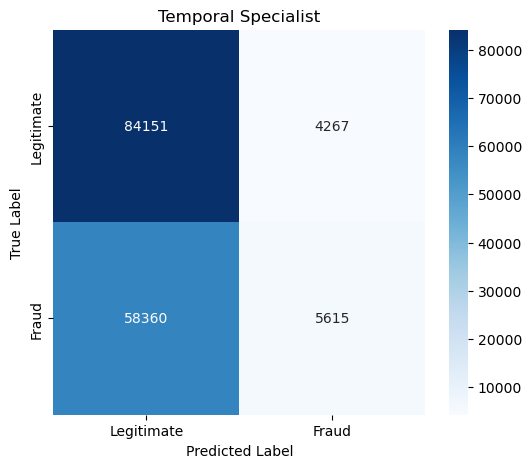

Temporal Specialist - Precision: 0.5682, Recall: 0.0878, F1: 0.1521
False Positives: 4267, False Negatives: 58360
Training Geographical Pattern Specialist...


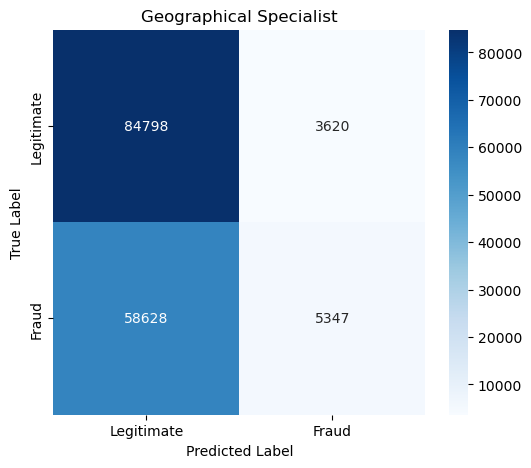

Geographical Specialist - Precision: 0.5963, Recall: 0.0836, F1: 0.1466
False Positives: 3620, False Negatives: 58628
Training Behavioral Pattern Specialist...


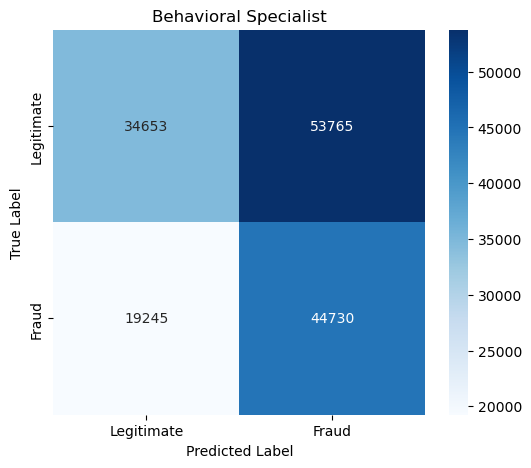

Behavioral Specialist - Precision: 0.4541, Recall: 0.6992, F1: 0.5506
False Positives: 53765, False Negatives: 19245
Training Composite Model...


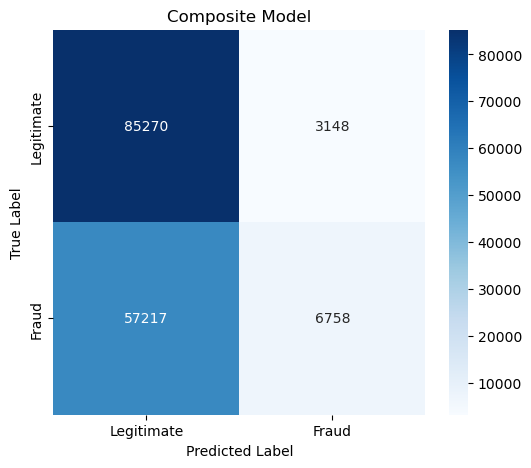

Composite Model - Precision: 0.6822, Recall: 0.1056, F1: 0.1829
False Positives: 3148, False Negatives: 57217
Training Meta-Model...

Multi-Model System Performance:
              precision    recall  f1-score   support

           0       0.59      0.99      0.74     88418
           1       0.80      0.06      0.11     63975

    accuracy                           0.60    152393
   macro avg       0.70      0.52      0.43    152393
weighted avg       0.68      0.60      0.48    152393



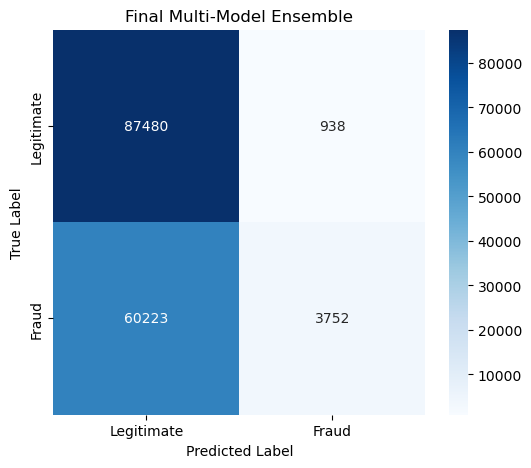

Final Multi-Model Ensemble - Precision: 0.8000, Recall: 0.0586, F1: 0.1093
False Positives: 938, False Negatives: 60223
Achieved Precision: 0.8000

Model Comparison Summary:
Model           | Precision | Recall  | F1     | Accuracy | AUC   
------------------------------------------------------------------
Temporal        |    0.5682 |  0.0878 | 0.1521 |   0.5890 | 0.6018
Geographical    |    0.5963 |  0.0836 | 0.1466 |   0.5915 | 0.5992
Behavioral      |    0.4541 |  0.6992 | 0.5506 |   0.5209 | 0.5647
Composite       |    0.6822 |  0.1056 | 0.1829 |   0.6039 | 0.6625
Ensemble        |    0.8000 |  0.0586 | 0.1093 |   0.5987 | 0.6620

Specialist Model AUC Scores:
Temporal Specialist AUC: 0.601751567174469
Geographical Specialist AUC: 0.5992374844307472
Behavioral Specialist AUC: 0.5647422097518227
Composite Model AUC: 0.662498641064521
Meta-Model AUC: 0.6620089954965503


In [13]:
# Multi-Model Fraud Detection System with Confusion Matrix Analysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, precision_score, roc_auc_score, recall_score, accuracy_score, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define feature groups based on importance
temporal_features = ['is_night', 'day_of_week', 'is_weekend', 'hour_of_day']
geographic_features = ['distance_from_home']
behavioral_features = ['velocity_kmh', 'transaction_count', 'client_age_days']
composite_features = ['geo_risk']

# Get indices for each feature group
temporal_indices = [feature_columns.index(f) for f in temporal_features]
geographic_indices = [feature_columns.index(f) for f in geographic_features]
behavioral_indices = [feature_columns.index(f) for f in behavioral_features]
composite_indices = [feature_columns.index(f) for f in composite_features]

# Create specialised feature sets
X_train_temporal = X_train[:, temporal_indices]
X_test_temporal = X_test[:, temporal_indices]

X_train_geo = X_train[:, geographic_indices]
X_test_geo = X_test[:, geographic_indices]

X_train_behavioral = X_train[:, behavioral_indices] 
X_test_behavioral = X_test[:, behavioral_indices]

X_train_composite = X_train[:, composite_indices]
X_test_composite = X_test[:, composite_indices]

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Legitimate', 'Fraud'], 
                yticklabels=['Legitimate', 'Fraud'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Calculate key metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{title} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(f"False Positives: {fp}, False Negatives: {fn}")
    return cm

# Model 1: Temporal Pattern Specialist
print("Training Temporal Pattern Specialist...")
temporal_model = LogisticRegression(
    class_weight={0: 1, 1: 0.7},
    random_state=42,
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    C=0.1
)
temporal_model.fit(X_train_temporal, y_train)
y_pred_temporal = temporal_model.predict(X_test_temporal)
cm_temporal = plot_confusion_matrix(y_test, y_pred_temporal, "Temporal Specialist")

# Model 2: Geographical Pattern Specialist  
print("Training Geographical Pattern Specialist...")
geo_model = LogisticRegression(
    class_weight={0: 1, 1: 0.8},
    random_state=42,
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    C=0.2
)
geo_model.fit(X_train_geo, y_train)
y_pred_geo = geo_model.predict(X_test_geo)
cm_geo = plot_confusion_matrix(y_test, y_pred_geo, "Geographical Specialist")

# Model 3: Behavioral Pattern Specialist
print("Training Behavioral Pattern Specialist...")
behavioral_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight={0: 1, 1: 2},
    random_state=42
)
behavioral_model.fit(X_train_behavioral, y_train)
y_pred_behavioral = behavioral_model.predict(X_test_behavioral)
cm_behavioral = plot_confusion_matrix(y_test, y_pred_behavioral, "Behavioral Specialist")

# Model 4: Composite Model (All features)
print("Training Composite Model...")
composite_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=0.8,
    random_state=42
)
composite_model.fit(X_train, y_train)
y_pred_composite = composite_model.predict(X_test)
cm_composite = plot_confusion_matrix(y_test, y_pred_composite, "Composite Model")

# Get probability predictions from all specialists for ensemble
y_prob_temporal = temporal_model.predict_proba(X_test_temporal)[:, 1]
y_prob_geo = geo_model.predict_proba(X_test_geo)[:, 1] 
y_prob_behavioral = behavioral_model.predict_proba(X_test_behavioral)[:, 1]
y_prob_composite = composite_model.predict_proba(X_test)[:, 1]

# Create meta-features for ensemble
meta_features = np.column_stack([
    y_prob_temporal,
    y_prob_geo,
    y_prob_behavioral,
    y_prob_composite
])

# Also create on training set for meta-model training
y_prob_temporal_train = temporal_model.predict_proba(X_train_temporal)[:, 1]
y_prob_geo_train = geo_model.predict_proba(X_train_geo)[:, 1]
y_prob_behavioral_train = behavioral_model.predict_proba(X_train_behavioral)[:, 1]
y_prob_composite_train = composite_model.predict_proba(X_train)[:, 1]

meta_features_train = np.column_stack([
    y_prob_temporal_train,
    y_prob_geo_train,
    y_prob_behavioral_train,
    y_prob_composite_train
])

# Train meta-model to combine specialist predictions
print("Training Meta-Model...")
meta_model = LogisticRegression(
    class_weight={0: 1, 1: 0.6},
    random_state=42,
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    C=0.05
)
meta_model.fit(meta_features_train, y_train)

# Get final predictions from meta-model
y_prob_meta = meta_model.predict_proba(meta_features)[:, 1]

# Find optimal threshold for high precision
precision_meta, recall_meta, thresholds_meta = precision_recall_curve(y_test, y_prob_meta)
target_precision = 0.8
high_precision_idx = np.where(precision_meta >= target_precision)[0]

if len(high_precision_idx) > 0:
    optimal_threshold = thresholds_meta[high_precision_idx[0]]
    y_pred_final = (y_prob_meta >= optimal_threshold).astype(int)
    
    print("\nMulti-Model System Performance:")
    print(classification_report(y_test, y_pred_final))
    
    # Plot final confusion matrix
    cm_final = plot_confusion_matrix(y_test, y_pred_final, "Final Multi-Model Ensemble")
    
    print(f"Achieved Precision: {precision_score(y_test, y_pred_final):.4f}")
else:
    print(f"Cannot achieve {target_precision:.0%} precision with multi-model system")

# Comprehensive Model Comparison Summary
print("\nModel Comparison Summary:")
print("=" * 66)
models = {
    "Temporal": y_pred_temporal,
    "Geographical": y_pred_geo,
    "Behavioral": y_pred_behavioral,
    "Composite": y_pred_composite,
    "Ensemble": y_pred_final
}

print(f"{'Model':15} | {'Precision':9} | {'Recall':7} | {'F1':6} | {'Accuracy':8} | {'AUC':6}")
print("-" * 66)

for name, preds in models.items():
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)
    
    # Get AUC scores for relevant models
    if name == "Temporal":
        auc_score = roc_auc_score(y_test, y_prob_temporal)
    elif name == "Geographical":
        auc_score = roc_auc_score(y_test, y_prob_geo)
    elif name == "Behavioral":
        auc_score = roc_auc_score(y_test, y_prob_behavioral)
    elif name == "Composite":
        auc_score = roc_auc_score(y_test, y_prob_composite)
    elif name == "Ensemble":
        auc_score = roc_auc_score(y_test, y_prob_meta)
    
    print(f"{name:15} | {precision:9.4f} | {recall:7.4f} | {f1:6.4f} | {accuracy:8.4f} | {auc_score:6.4f}")

print("=" * 66)

# Analyze specialist performance with AUC
print("\nSpecialist Model AUC Scores:")
print("Temporal Specialist AUC:", roc_auc_score(y_test, y_prob_temporal))
print("Geographical Specialist AUC:", roc_auc_score(y_test, y_prob_geo))
print("Behavioral Specialist AUC:", roc_auc_score(y_test, y_prob_behavioral))
print("Composite Model AUC:", roc_auc_score(y_test, y_prob_composite))
print("Meta-Model AUC:", roc_auc_score(y_test, y_prob_meta))

<h3><strong>4b.1. Accuracy Focused Model (Without GridSearchCV)</strong></h3>

Training Temporal Pattern Specialist...


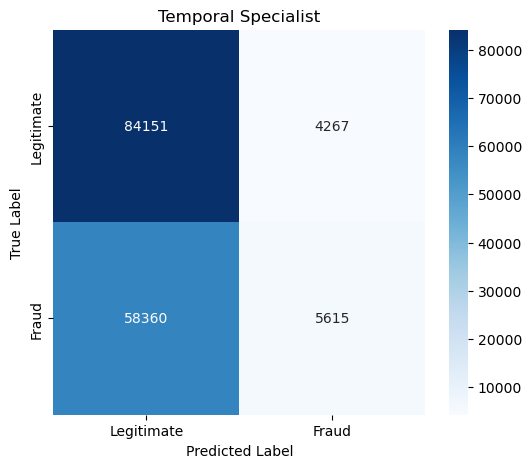

Temporal Specialist - Accuracy: 0.5890, Precision: 0.5682, Recall: 0.0878, F1: 0.1521
False Positives: 4267, False Negatives: 58360
Training Geographical Pattern Specialist...


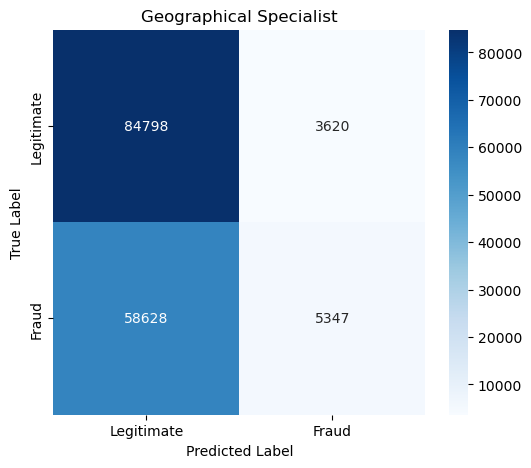

Geographical Specialist - Accuracy: 0.5915, Precision: 0.5963, Recall: 0.0836, F1: 0.1466
False Positives: 3620, False Negatives: 58628
Training Behavioral Pattern Specialist...


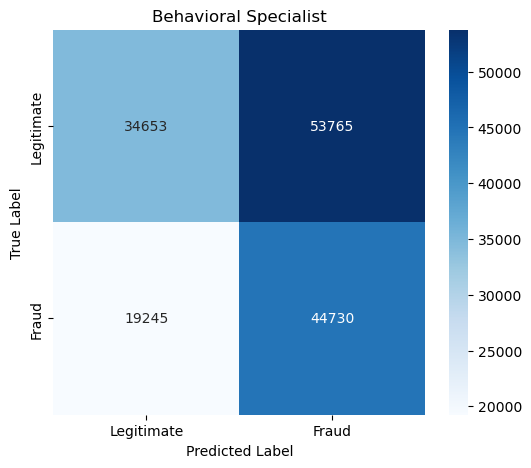

Behavioral Specialist - Accuracy: 0.5209, Precision: 0.4541, Recall: 0.6992, F1: 0.5506
False Positives: 53765, False Negatives: 19245
Training Composite Model...


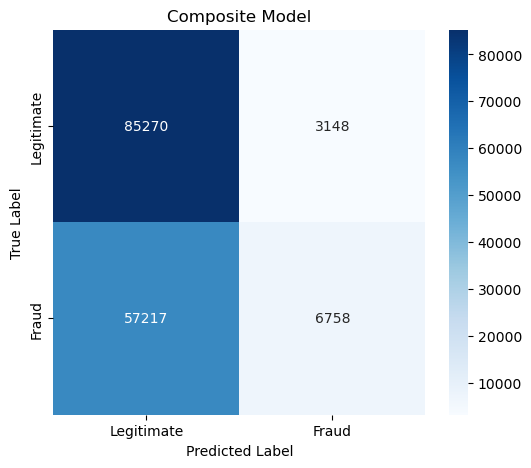

Composite Model - Accuracy: 0.6039, Precision: 0.6822, Recall: 0.1056, F1: 0.1829
False Positives: 3148, False Negatives: 57217
Training Meta-Model...

Multi-Model System Performance (Optimized for Accuracy):
              precision    recall  f1-score   support

           0       0.63      0.78      0.70     88418
           1       0.55      0.37      0.44     63975

    accuracy                           0.61    152393
   macro avg       0.59      0.57      0.57    152393
weighted avg       0.60      0.61      0.59    152393



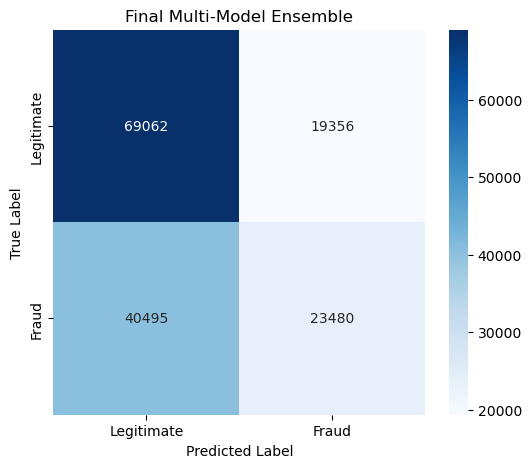

Final Multi-Model Ensemble - Accuracy: 0.6073, Precision: 0.5481, Recall: 0.3670, F1: 0.4397
False Positives: 19356, False Negatives: 40495
Optimal Threshold for Accuracy: 0.3900
Achieved Accuracy: 0.6073

Model Comparison Summary:
Model           | Accuracy | Precision | Recall  | F1     | AUC   
------------------------------------------------------------------
Temporal        |   0.5890 |    0.5682 |  0.0878 | 0.1521 | 0.6018
Geographical    |   0.5915 |    0.5963 |  0.0836 | 0.1466 | 0.5992
Behavioral      |   0.5209 |    0.4541 |  0.6992 | 0.5506 | 0.5647
Composite       |   0.6039 |    0.6822 |  0.1056 | 0.1829 | 0.6625
Ensemble        |   0.6073 |    0.5481 |  0.3670 | 0.4397 | 0.6620

Specialist Model AUC Scores:
Temporal Specialist AUC: 0.601751567174469
Geographical Specialist AUC: 0.5992374844307472
Behavioral Specialist AUC: 0.5647422097518227
Composite Model AUC: 0.662498641064521
Meta-Model AUC: 0.6620089954965503


In [14]:
# Multi-Model Fraud Detection System with Confusion Matrix Analysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, precision_score, roc_auc_score, recall_score, accuracy_score, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define feature groups based on importance
temporal_features = ['is_night', 'day_of_week', 'is_weekend', 'hour_of_day']
geographic_features = ['distance_from_home']
behavioral_features = ['velocity_kmh', 'transaction_count', 'client_age_days']
composite_features = ['geo_risk']

# Get indices for each feature group
temporal_indices = [feature_columns.index(f) for f in temporal_features]
geographic_indices = [feature_columns.index(f) for f in geographic_features]
behavioral_indices = [feature_columns.index(f) for f in behavioral_features]
composite_indices = [feature_columns.index(f) for f in composite_features]

# Create specialised feature sets
X_train_temporal = X_train[:, temporal_indices]
X_test_temporal = X_test[:, temporal_indices]

X_train_geo = X_train[:, geographic_indices]
X_test_geo = X_test[:, geographic_indices]

X_train_behavioral = X_train[:, behavioral_indices] 
X_test_behavioral = X_test[:, behavioral_indices]

X_train_composite = X_train[:, composite_indices]
X_test_composite = X_test[:, composite_indices]

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Legitimate', 'Fraud'], 
                yticklabels=['Legitimate', 'Fraud'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Calculate key metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    
    print(f"{title} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(f"False Positives: {fp}, False Negatives: {fn}")
    return cm

# Model 1: Temporal Pattern Specialist
print("Training Temporal Pattern Specialist...")
temporal_model = LogisticRegression(
    class_weight={0: 1, 1: 0.7},
    random_state=42,
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    C=0.1
)
temporal_model.fit(X_train_temporal, y_train)
y_pred_temporal = temporal_model.predict(X_test_temporal)
cm_temporal = plot_confusion_matrix(y_test, y_pred_temporal, "Temporal Specialist")

# Model 2: Geographical Pattern Specialist  
print("Training Geographical Pattern Specialist...")
geo_model = LogisticRegression(
    class_weight={0: 1, 1: 0.8},
    random_state=42,
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    C=0.2
)
geo_model.fit(X_train_geo, y_train)
y_pred_geo = geo_model.predict(X_test_geo)
cm_geo = plot_confusion_matrix(y_test, y_pred_geo, "Geographical Specialist")

# Model 3: Behavioral Pattern Specialist
print("Training Behavioral Pattern Specialist...")
behavioral_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight={0: 1, 1: 2},
    random_state=42
)
behavioral_model.fit(X_train_behavioral, y_train)
y_pred_behavioral = behavioral_model.predict(X_test_behavioral)
cm_behavioral = plot_confusion_matrix(y_test, y_pred_behavioral, "Behavioral Specialist")

# Model 4: Composite Model (All features)
print("Training Composite Model...")
composite_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=0.8,
    random_state=42
)
composite_model.fit(X_train, y_train)
y_pred_composite = composite_model.predict(X_test)
cm_composite = plot_confusion_matrix(y_test, y_pred_composite, "Composite Model")

# Get probability predictions from all specialists for ensemble
y_prob_temporal = temporal_model.predict_proba(X_test_temporal)[:, 1]
y_prob_geo = geo_model.predict_proba(X_test_geo)[:, 1] 
y_prob_behavioral = behavioral_model.predict_proba(X_test_behavioral)[:, 1]
y_prob_composite = composite_model.predict_proba(X_test)[:, 1]

# Create meta-features for ensemble
meta_features = np.column_stack([
    y_prob_temporal,
    y_prob_geo,
    y_prob_behavioral,
    y_prob_composite
])

# Also create on training set for meta-model training
y_prob_temporal_train = temporal_model.predict_proba(X_train_temporal)[:, 1]
y_prob_geo_train = geo_model.predict_proba(X_train_geo)[:, 1]
y_prob_behavioral_train = behavioral_model.predict_proba(X_train_behavioral)[:, 1]
y_prob_composite_train = composite_model.predict_proba(X_train)[:, 1]

meta_features_train = np.column_stack([
    y_prob_temporal_train,
    y_prob_geo_train,
    y_prob_behavioral_train,
    y_prob_composite_train
])

# Train meta-model to combine specialist predictions
print("Training Meta-Model...")
meta_model = LogisticRegression(
    class_weight={0: 1, 1: 0.6},
    random_state=42,
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    C=0.05
)
meta_model.fit(meta_features_train, y_train)

# Get final predictions from meta-model
y_prob_meta = meta_model.predict_proba(meta_features)[:, 1]

# Find optimal threshold for maximum accuracy instead of high precision
# We'll test multiple thresholds and select the one with highest accuracy
thresholds = np.arange(0.1, 0.9, 0.01)
accuracies = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_meta >= threshold).astype(int)
    accuracies.append(accuracy_score(y_test, y_pred_threshold))

# Find the threshold with maximum accuracy
best_idx = np.argmax(accuracies)
optimal_threshold = thresholds[best_idx]
y_pred_final = (y_prob_meta >= optimal_threshold).astype(int)

print("\nMulti-Model System Performance (Optimized for Accuracy):")
print(classification_report(y_test, y_pred_final))

# Plot final confusion matrix
cm_final = plot_confusion_matrix(y_test, y_pred_final, "Final Multi-Model Ensemble")

print(f"Optimal Threshold for Accuracy: {optimal_threshold:.4f}")
print(f"Achieved Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")

# Comprehensive Model Comparison Summary
print("\nModel Comparison Summary:")
print("=" * 66)
models = {
    "Temporal": y_pred_temporal,
    "Geographical": y_pred_geo,
    "Behavioral": y_pred_behavioral,
    "Composite": y_pred_composite,
    "Ensemble": y_pred_final
}

print(f"{'Model':15} | {'Accuracy':8} | {'Precision':9} | {'Recall':7} | {'F1':6} | {'AUC':6}")
print("-" * 66)

for name, preds in models.items():
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)
    
    # Get AUC scores for relevant models
    if name == "Temporal":
        auc_score = roc_auc_score(y_test, y_prob_temporal)
    elif name == "Geographical":
        auc_score = roc_auc_score(y_test, y_prob_geo)
    elif name == "Behavioral":
        auc_score = roc_auc_score(y_test, y_prob_behavioral)
    elif name == "Composite":
        auc_score = roc_auc_score(y_test, y_prob_composite)
    elif name == "Ensemble":
        auc_score = roc_auc_score(y_test, y_prob_meta)
    
    print(f"{name:15} | {accuracy:8.4f} | {precision:9.4f} | {recall:7.4f} | {f1:6.4f} | {auc_score:6.4f}")

print("=" * 66)

# Analyze specialist performance with AUC
print("\nSpecialist Model AUC Scores:")
print("Temporal Specialist AUC:", roc_auc_score(y_test, y_prob_temporal))
print("Geographical Specialist AUC:", roc_auc_score(y_test, y_prob_geo))
print("Behavioral Specialist AUC:", roc_auc_score(y_test, y_prob_behavioral))
print("Composite Model AUC:", roc_auc_score(y_test, y_prob_composite))
print("Meta-Model AUC:", roc_auc_score(y_test, y_prob_meta))

<h3><strong>4b.2. Accuracy Focused Model (With GridSearchCV)</strong></h3>

Training Temporal Pattern Specialist with GridSearchCV...
Best parameters for Temporal Model: {'C': 0.01, 'class_weight': {0: 1, 1: 1.5}, 'penalty': 'l1', 'solver': 'liblinear'}


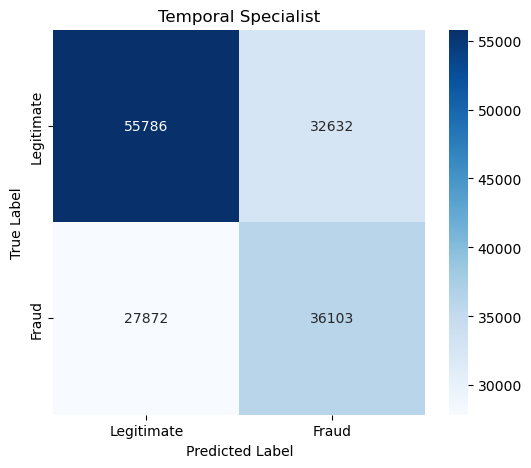

Temporal Specialist - Accuracy: 0.6030, Precision: 0.5252, Recall: 0.5643, F1: 0.5441
False Positives: 32632, False Negatives: 27872
Training Geographical Pattern Specialist with GridSearchCV...
Best parameters for Geographical Model: {'C': 0.1, 'class_weight': {0: 1, 1: 1.0}, 'penalty': 'l1', 'solver': 'liblinear'}


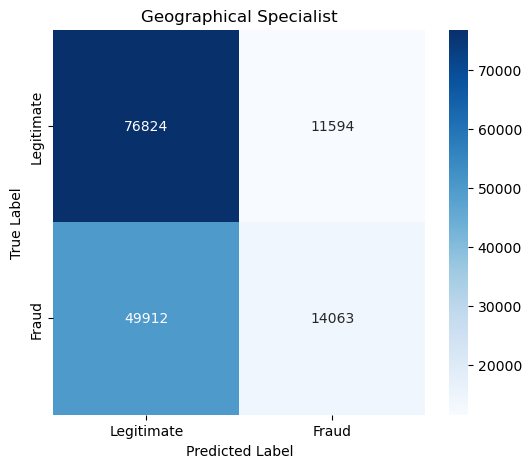

Geographical Specialist - Accuracy: 0.5964, Precision: 0.5481, Recall: 0.2198, F1: 0.3138
False Positives: 11594, False Negatives: 49912
Training Behavioral Pattern Specialist with GridSearchCV...
Best parameters for Behavioral Model: {'class_weight': {0: 1, 1: 1.5}, 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 200}


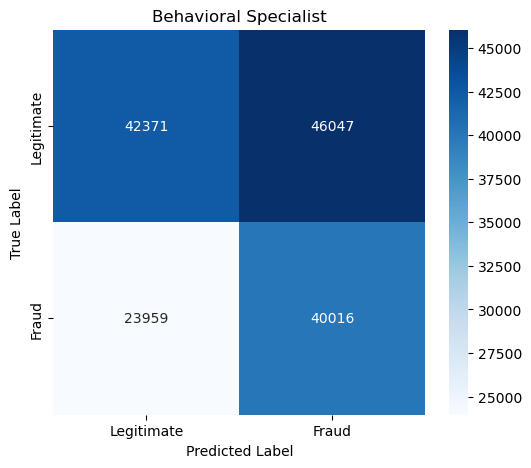

Behavioral Specialist - Accuracy: 0.5406, Precision: 0.4650, Recall: 0.6255, F1: 0.5334
False Positives: 46047, False Negatives: 23959
Training Composite Model with GridSearchCV...
Best parameters for Composite Model: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 1.0}


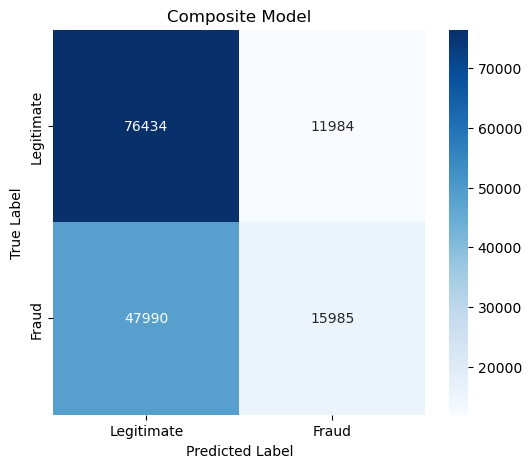

Composite Model - Accuracy: 0.6065, Precision: 0.5715, Recall: 0.2499, F1: 0.3477
False Positives: 11984, False Negatives: 47990
Training Meta-Model with GridSearchCV...
Best parameters for Meta Model: {'C': 0.01, 'class_weight': {0: 1, 1: 1.0}, 'penalty': 'l2', 'solver': 'liblinear'}

Multi-Model System Performance (Optimized for Accuracy):
              precision    recall  f1-score   support

           0       0.67      0.63      0.65     88418
           1       0.53      0.57      0.55     63975

    accuracy                           0.61    152393
   macro avg       0.60      0.60      0.60    152393
weighted avg       0.61      0.61      0.61    152393



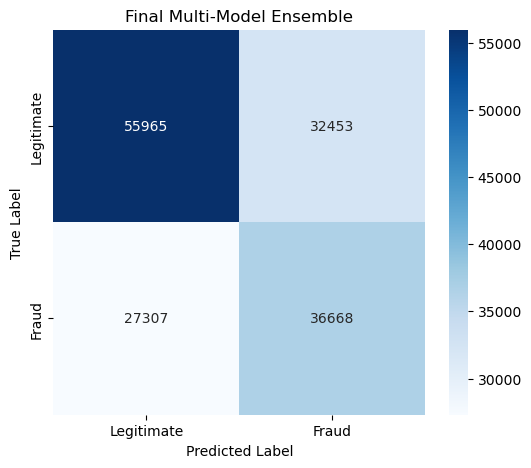

Final Multi-Model Ensemble - Accuracy: 0.6079, Precision: 0.5305, Recall: 0.5732, F1: 0.5510
False Positives: 32453, False Negatives: 27307
Optimal Threshold for Accuracy: 0.4700
Achieved Accuracy: 0.6079

Model Comparison Summary:
Model           | Accuracy | Precision | Recall  | F1     | AUC   
------------------------------------------------------------------
Temporal        |   0.6030 |    0.5252 |  0.5643 | 0.5441 | 0.6018
Geographical    |   0.5964 |    0.5481 |  0.2198 | 0.3138 | 0.5992
Behavioral      |   0.5406 |    0.4650 |  0.6255 | 0.5334 | 0.5645
Composite       |   0.6065 |    0.5715 |  0.2499 | 0.3477 | 0.6614
Ensemble        |   0.6079 |    0.5305 |  0.5732 | 0.5510 | 0.6616

Specialist Model AUC Scores:
Temporal Specialist AUC: 0.6017691992380043
Geographical Specialist AUC: 0.5992374844307472
Behavioral Specialist AUC: 0.5645335345410837
Composite Model AUC: 0.6614402217199307
Meta-Model AUC: 0.6615618201372533


In [15]:
# Multi-Model Fraud Detection System with Confusion Matrix Analysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, precision_score, roc_auc_score, recall_score, accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define feature groups based on importance
temporal_features = ['is_night', 'day_of_week', 'is_weekend', 'hour_of_day']
geographic_features = ['distance_from_home']
behavioral_features = ['velocity_kmh', 'transaction_count', 'client_age_days']
composite_features = ['geo_risk']

# Get indices for each feature group
temporal_indices = [feature_columns.index(f) for f in temporal_features]
geographic_indices = [feature_columns.index(f) for f in geographic_features]
behavioral_indices = [feature_columns.index(f) for f in behavioral_features]
composite_indices = [feature_columns.index(f) for f in composite_features]

# Create specialised feature sets
X_train_temporal = X_train[:, temporal_indices]
X_test_temporal = X_test[:, temporal_indices]

X_train_geo = X_train[:, geographic_indices]
X_test_geo = X_test[:, geographic_indices]

X_train_behavioral = X_train[:, behavioral_indices] 
X_test_behavioral = X_test[:, behavioral_indices]

X_train_composite = X_train[:, composite_indices]
X_test_composite = X_test[:, composite_indices]

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Legitimate', 'Fraud'], 
                yticklabels=['Legitimate', 'Fraud'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Calculate key metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    
    print(f"{title} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(f"False Positives: {fp}, False Negatives: {fn}")
    return cm

# Model 1: Temporal Pattern Specialist with GridSearchCV
print("Training Temporal Pattern Specialist with GridSearchCV...")
temporal_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'class_weight': [{0: 1, 1: w} for w in [0.5, 0.7, 1.0, 1.5]],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

temporal_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=temporal_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
temporal_grid.fit(X_train_temporal, y_train)
temporal_model = temporal_grid.best_estimator_
print(f"Best parameters for Temporal Model: {temporal_grid.best_params_}")

y_pred_temporal = temporal_model.predict(X_test_temporal)
cm_temporal = plot_confusion_matrix(y_test, y_pred_temporal, "Temporal Specialist")

# Model 2: Geographical Pattern Specialist with GridSearchCV
print("Training Geographical Pattern Specialist with GridSearchCV...")
geo_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'class_weight': [{0: 1, 1: w} for w in [0.5, 0.8, 1.0, 1.5]],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

geo_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=geo_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
geo_grid.fit(X_train_geo, y_train)
geo_model = geo_grid.best_estimator_
print(f"Best parameters for Geographical Model: {geo_grid.best_params_}")

y_pred_geo = geo_model.predict(X_test_geo)
cm_geo = plot_confusion_matrix(y_test, y_pred_geo, "Geographical Specialist")

# Model 3: Behavioral Pattern Specialist with GridSearchCV
print("Training Behavioral Pattern Specialist with GridSearchCV...")
behavioral_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'class_weight': [{0: 1, 1: w} for w in [1.5, 2, 3]]
}

behavioral_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=behavioral_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
behavioral_grid.fit(X_train_behavioral, y_train)
behavioral_model = behavioral_grid.best_estimator_
print(f"Best parameters for Behavioral Model: {behavioral_grid.best_params_}")

y_pred_behavioral = behavioral_model.predict(X_test_behavioral)
cm_behavioral = plot_confusion_matrix(y_test, y_pred_behavioral, "Behavioral Specialist")

# Model 4: Composite Model with GridSearchCV
print("Training Composite Model with GridSearchCV...")
composite_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [0.5, 0.8, 1.0]
}

composite_grid = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid=composite_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
composite_grid.fit(X_train, y_train)
composite_model = composite_grid.best_estimator_
print(f"Best parameters for Composite Model: {composite_grid.best_params_}")

y_pred_composite = composite_model.predict(X_test)
cm_composite = plot_confusion_matrix(y_test, y_pred_composite, "Composite Model")

# Get probability predictions from all specialists for ensemble
y_prob_temporal = temporal_model.predict_proba(X_test_temporal)[:, 1]
y_prob_geo = geo_model.predict_proba(X_test_geo)[:, 1] 
y_prob_behavioral = behavioral_model.predict_proba(X_test_behavioral)[:, 1]
y_prob_composite = composite_model.predict_proba(X_test)[:, 1]

# Create meta-features for ensemble
meta_features = np.column_stack([
    y_prob_temporal,
    y_prob_geo,
    y_prob_behavioral,
    y_prob_composite
])

# Also create on training set for meta-model training
y_prob_temporal_train = temporal_model.predict_proba(X_train_temporal)[:, 1]
y_prob_geo_train = geo_model.predict_proba(X_train_geo)[:, 1]
y_prob_behavioral_train = behavioral_model.predict_proba(X_train_behavioral)[:, 1]
y_prob_composite_train = composite_model.predict_proba(X_train)[:, 1]

meta_features_train = np.column_stack([
    y_prob_temporal_train,
    y_prob_geo_train,
    y_prob_behavioral_train,
    y_prob_composite_train
])

# Train meta-model with GridSearchCV to combine specialist predictions
print("Training Meta-Model with GridSearchCV...")
meta_param_grid = {
    'C': [0.01, 0.05, 0.1, 1.0],
    'class_weight': [{0: 1, 1: w} for w in [0.5, 0.6, 0.8, 1.0]],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

meta_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=meta_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
meta_grid.fit(meta_features_train, y_train)
meta_model = meta_grid.best_estimator_
print(f"Best parameters for Meta Model: {meta_grid.best_params_}")

# Get final predictions from meta-model
y_prob_meta = meta_model.predict_proba(meta_features)[:, 1]

# Find optimal threshold for maximum accuracy
thresholds = np.arange(0.1, 0.9, 0.01)
accuracies = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_meta >= threshold).astype(int)
    accuracies.append(accuracy_score(y_test, y_pred_threshold))

# Find the threshold with maximum accuracy
best_idx = np.argmax(accuracies)
optimal_threshold = thresholds[best_idx]
y_pred_final = (y_prob_meta >= optimal_threshold).astype(int)

print("\nMulti-Model System Performance (Optimized for Accuracy):")
print(classification_report(y_test, y_pred_final))

# Plot final confusion matrix
cm_final = plot_confusion_matrix(y_test, y_pred_final, "Final Multi-Model Ensemble")

print(f"Optimal Threshold for Accuracy: {optimal_threshold:.4f}")
print(f"Achieved Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")

# Comprehensive Model Comparison Summary
print("\nModel Comparison Summary:")
print("=" * 66)
models = {
    "Temporal": y_pred_temporal,
    "Geographical": y_pred_geo,
    "Behavioral": y_pred_behavioral,
    "Composite": y_pred_composite,
    "Ensemble": y_pred_final
}

print(f"{'Model':15} | {'Accuracy':8} | {'Precision':9} | {'Recall':7} | {'F1':6} | {'AUC':6}")
print("-" * 66)

for name, preds in models.items():
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)
    
    # Get AUC scores for relevant models
    if name == "Temporal":
        auc_score = roc_auc_score(y_test, y_prob_temporal)
    elif name == "Geographical":
        auc_score = roc_auc_score(y_test, y_prob_geo)
    elif name == "Behavioral":
        auc_score = roc_auc_score(y_test, y_prob_behavioral)
    elif name == "Composite":
        auc_score = roc_auc_score(y_test, y_prob_composite)
    elif name == "Ensemble":
        auc_score = roc_auc_score(y_test, y_prob_meta)
    
    print(f"{name:15} | {accuracy:8.4f} | {precision:9.4f} | {recall:7.4f} | {f1:6.4f} | {auc_score:6.4f}")

print("=" * 66)

# Analyze specialist performance with AUC
print("\nSpecialist Model AUC Scores:")
print("Temporal Specialist AUC:", roc_auc_score(y_test, y_prob_temporal))
print("Geographical Specialist AUC:", roc_auc_score(y_test, y_prob_geo))
print("Behavioral Specialist AUC:", roc_auc_score(y_test, y_prob_behavioral))
print("Composite Model AUC:", roc_auc_score(y_test, y_prob_composite))
print("Meta-Model AUC:", roc_auc_score(y_test, y_prob_meta))

Top 10 features by absolute SHAP value:
           feature  mean_abs_shap
distance_from_home       0.314191
          is_night       0.262507
       day_of_week       0.246957
      velocity_kmh       0.074388
 transaction_count       0.060362
          geo_risk       0.021969
   client_age_days       0.002163
       hour_of_day       0.000033
        is_weekend       0.000000


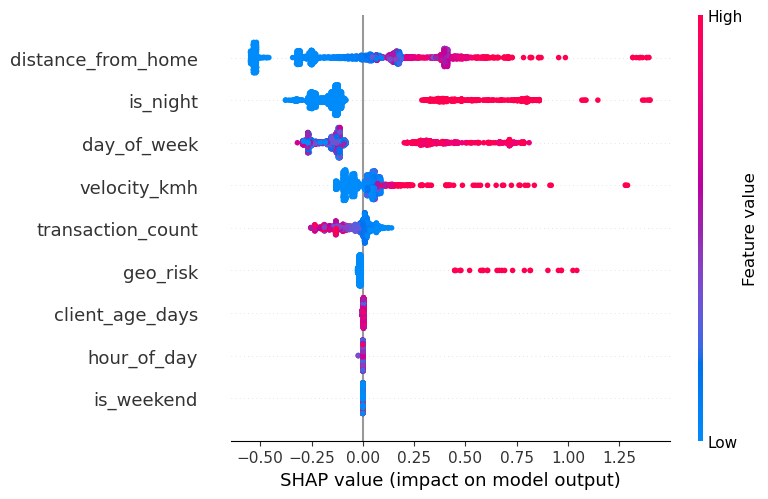

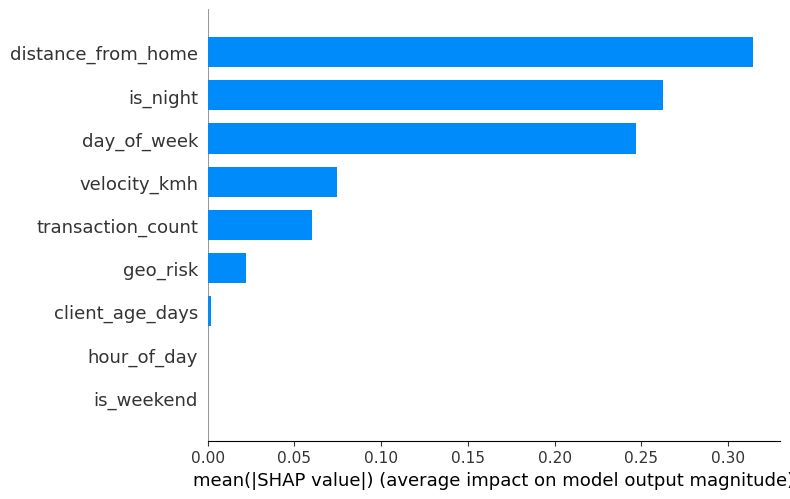

In [16]:
# SHAP feature importance for the composite XGBoost model
import shap

rng = np.random.default_rng(42)
background_size = min(1000, X_train.shape[0])
validation_size = min(2000, X_test.shape[0])

if background_size < X_train.shape[0]:
    background_idx = rng.choice(X_train.shape[0], size=background_size, replace=False)
else:
    background_idx = np.arange(X_train.shape[0])

if validation_size < X_test.shape[0]:
    validation_idx = rng.choice(X_test.shape[0], size=validation_size, replace=False)
else:
    validation_idx = np.arange(X_test.shape[0])

background_data = X_train[background_idx]
validation_data = X_test[validation_idx]
validation_df = pd.DataFrame(validation_data, columns=feature_columns)

explainer = shap.TreeExplainer(composite_model, data=background_data)
shap_values = explainer.shap_values(validation_data)

mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
shap_importance = (
    pd.DataFrame({'feature': feature_columns, 'mean_abs_shap': mean_abs_shap})
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print('Top 10 features by absolute SHAP value:')
print(shap_importance.head(10).to_string(index=False))

shap.summary_plot(shap_values, validation_df, show=True)
shap.summary_plot(shap_values, validation_df, plot_type='bar', show=True)
